# Simulating Korea COVID-19 Data (2020-2023)

This simulation runs Covasim with different parameters and calibration points.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import covasim as cv

plt.style.use('seaborn-v0_8')

Covasim 3.1.7 (2026-02-18) — © 2020-2026 by IDM


In [2]:
covasim_df = pd.read_csv("/mnt/c/Users/jhkim/OneDrive - The Scripps Research Institute/jhk_covasim4wastewater/simulation_korea/korea_clean_for_covasim.csv")
covasim_df["date"] = pd.to_datetime(covasim_df["date"])
covasim_df.head()

,date,new_diagnoses,new_deaths
0,2020-01-20,1.0,0.0
1,2020-01-21,0.0,0.0
2,2020-01-22,0.0,0.0
3,2020-01-23,0.0,0.0
4,2020-01-24,1.0,0.0


# Visualizing the Epidemic Curves

We now visualize:
- Daily new diagnoses  
- Daily deaths  

These plots provide a high‑level overview of the epidemic trajectory in Korea.

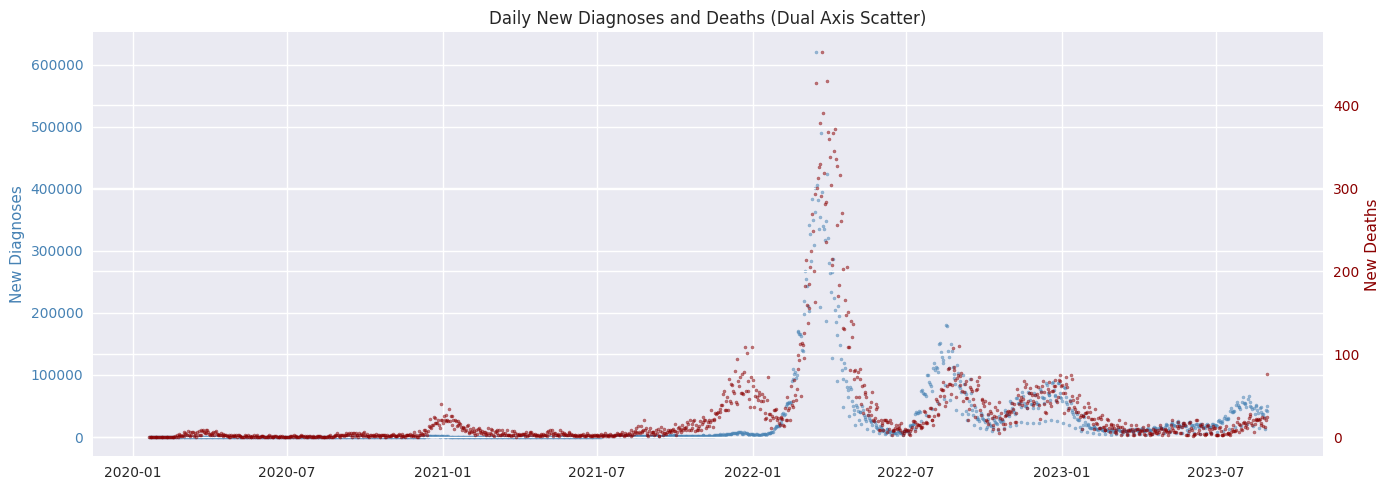

In [3]:
fig, ax1 = plt.subplots(figsize=(14,5))

ax1.scatter(covasim_df["date"], covasim_df["new_diagnoses"], s=5, color="steelblue", alpha=0.5)
ax1.set_ylabel("New Diagnoses", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.scatter(covasim_df["date"], covasim_df["new_deaths"], s=5, color="darkred", alpha=0.5)
ax2.set_ylabel("New Deaths", color="darkred")
ax2.tick_params(axis="y", labelcolor="darkred")

plt.title("Daily New Diagnoses and Deaths (Dual Axis Scatter)")
fig.tight_layout()
plt.show()


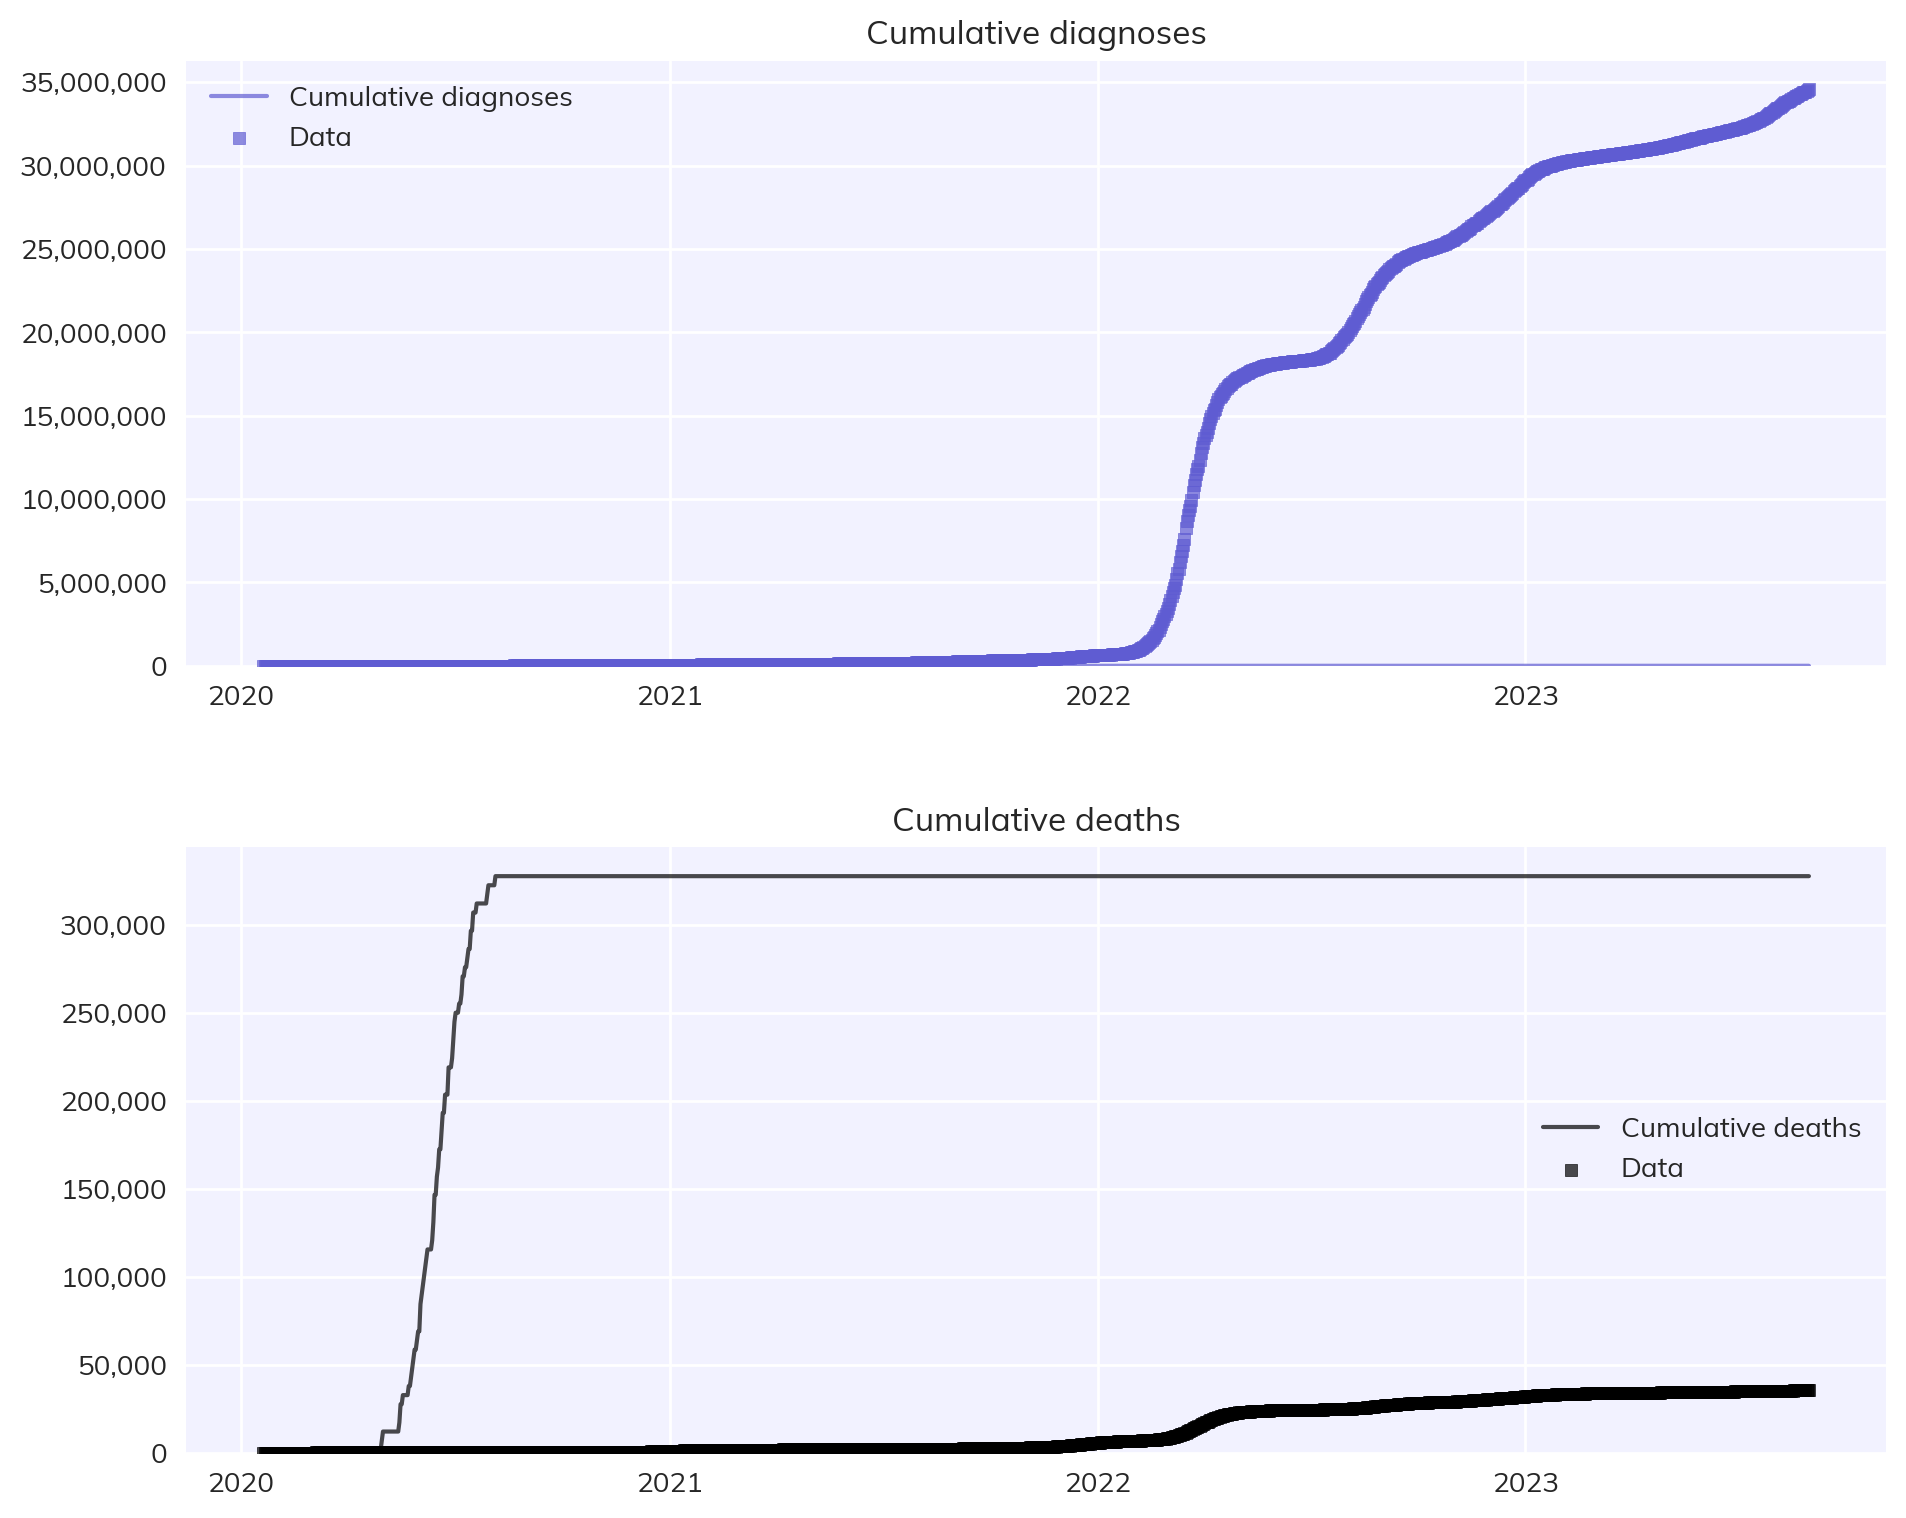

In [4]:
cv.options(jupyter=True, verbose=0)

pars = dict(
    pop_size  = 10_000,
    pop_scale=51780000/10000,
    start_day = '2020-01-20',
    end_day   = '2023-08-31',
)
sim = cv.Sim(pars=pars, datafile='/mnt/c/Users/jhkim/OneDrive - The Scripps Research Institute/jhk_covasim4wastewater/simulation_korea/korea_clean_for_covasim.csv')
sim.run()
sim.plot(to_plot=['cum_diagnoses', 'cum_deaths'])

/home/jhkim/miniconda3/envs/covasim4wastewater/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Could not delete study, skipping...
'Record does not exist.'
Removed existing calibration covasim_calibration.db


[I 2026-06-15 16:54:23,774] A new study created in RDB with name: covasim_calibration
[I 2026-06-15 16:54:29,215] Trial 12 finished with value: 1398.4029714617918 and parameters: {'beta': 0.0035446189905577077, 'rel_death_prob': 1.0535030032106854, 'pop_infected': 1816.5788242996543}. Best is trial 12 with value: 1398.4029714617918.
[I 2026-06-15 16:54:30,363] Trial 11 finished with value: 90552.91180013225 and parameters: {'beta': 0.02587828078369882, 'rel_death_prob': 0.904298576089297, 'pop_infected': 1167.0881248613528}. Best is trial 12 with value: 1398.4029714617918.
[I 2026-06-15 16:54:30,708] Trial 6 finished with value: 1405.666017300818 and parameters: {'beta': 0.004109525493372591, 'rel_death_prob': 0.39650312669094634, 'pop_infected': 1954.9872912326455}. Best is trial 12 with value: 1398.4029714617918.
[I 2026-06-15 16:54:33,700] Trial 3 finished with value: 91192.589920837 and parameters: {'beta': 0.07748951935541379, 'rel_death_prob': 0.4787882450630765, 'pop_infected': 

Making results structure...
Processed 216 trials; 0 failed
Deleted study covasim_calibration in sqlite:///covasim_calibration.db
Removed existing calibration covasim_calibration.db
Calibration for 216 total trials completed in 101.7 s.

Initial parameter values:
#0. 'beta':           0.02
#1. 'rel_death_prob': 1.0
#2. 'pop_infected':   200

Best parameter values:
#0. 'beta':           0.006567855167714793
#1. 'rel_death_prob': 2.9220396977331213
#2. 'pop_infected':   3713.530231438081

Mismatch before calibration: 100056
Mismatch after calibration:  1219.33
Percent improvement:         98.8%


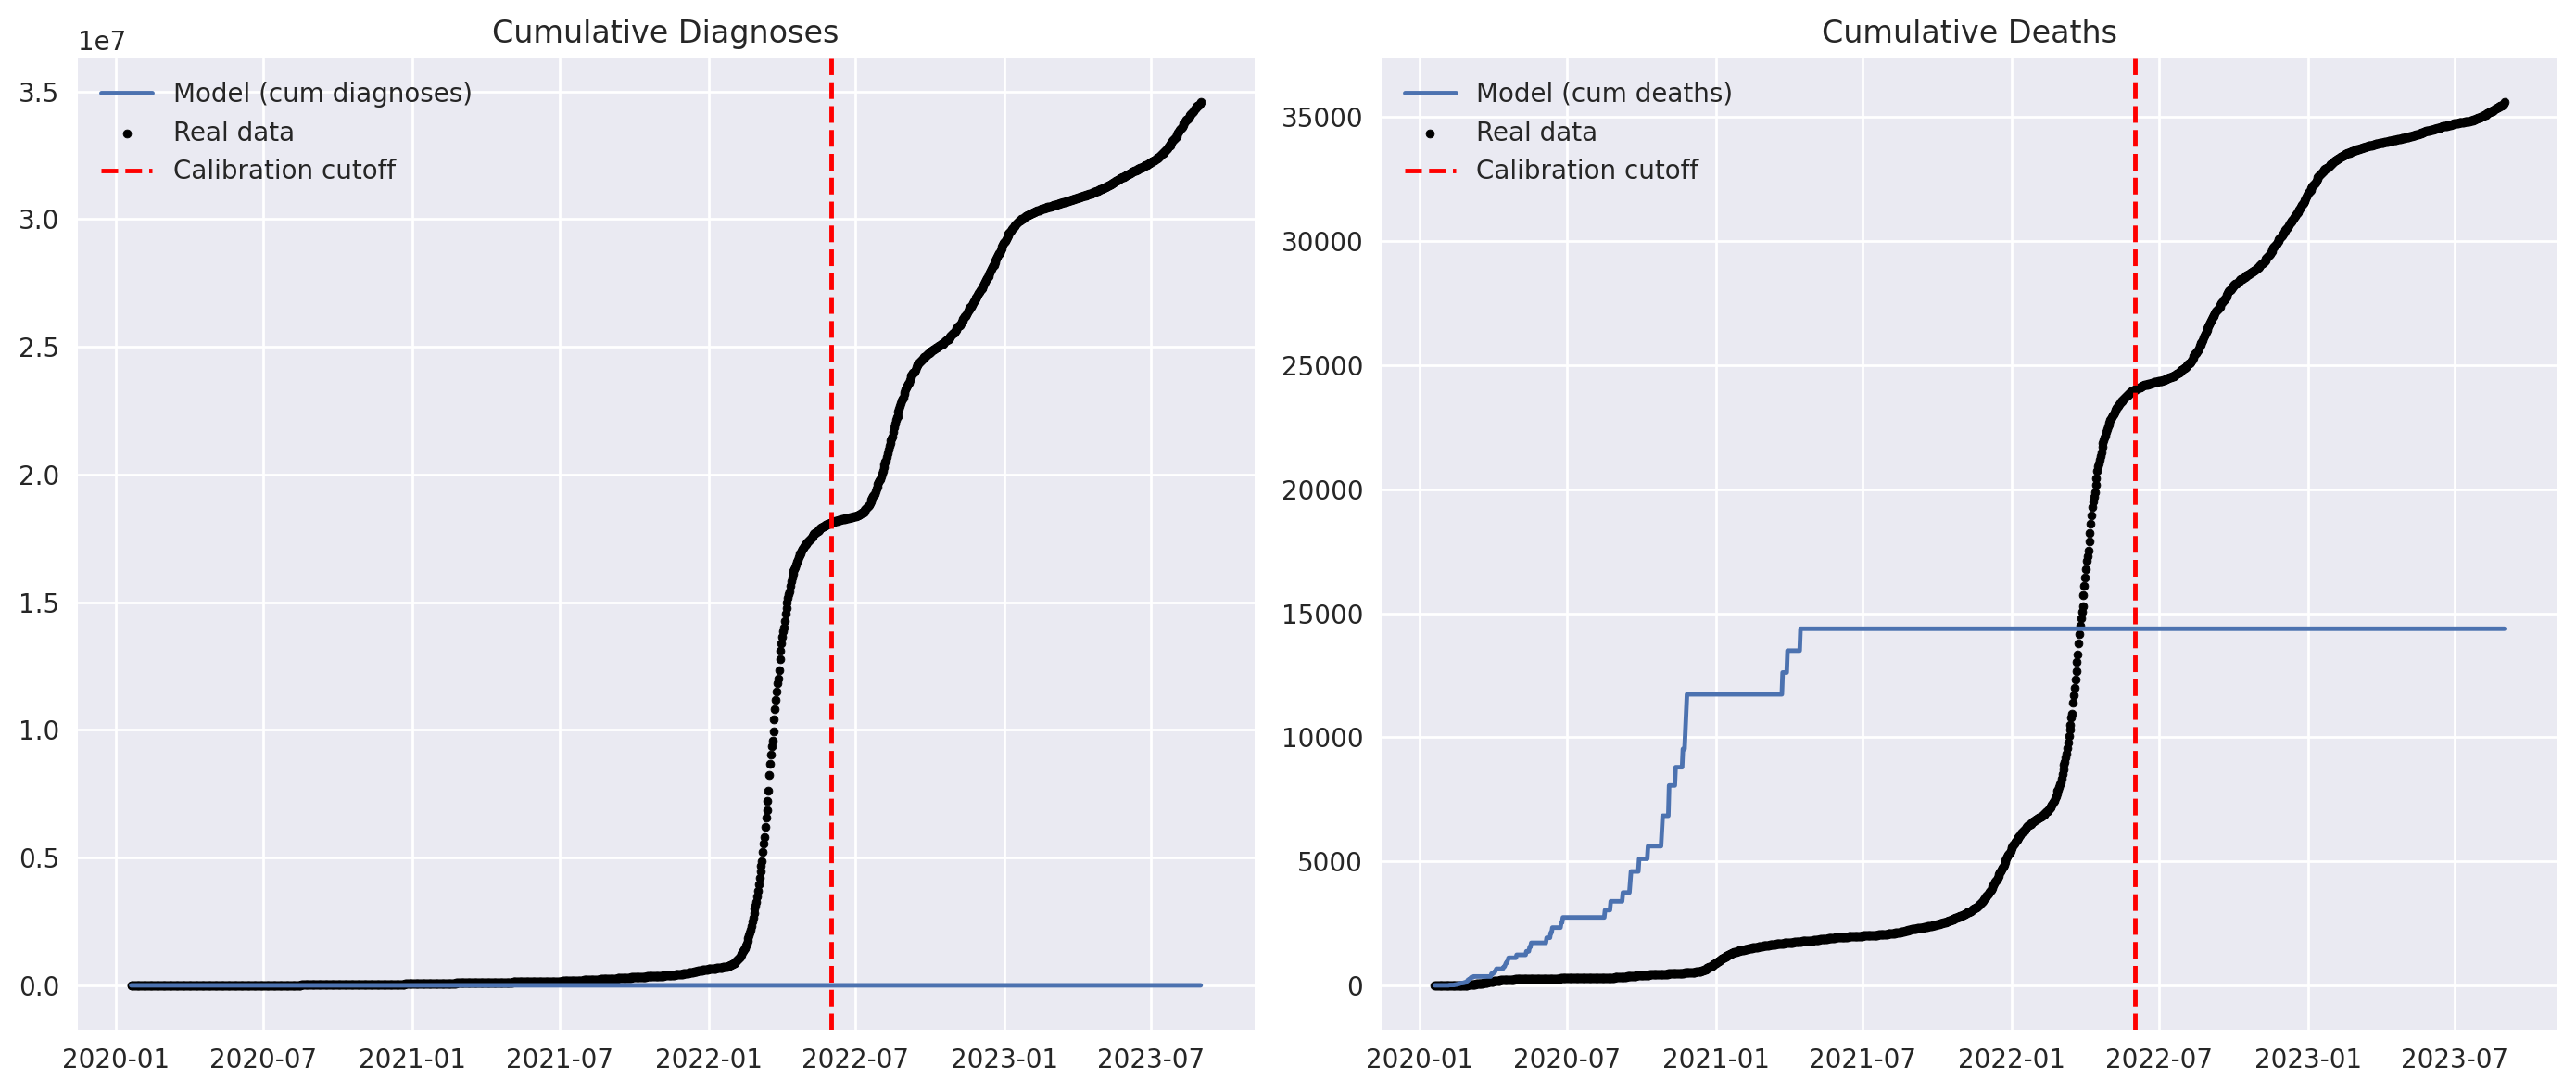

In [5]:
# data prep
df = covasim_df.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

df["cum_diagnoses"] = df["new_diagnoses"].cumsum()
df["cum_deaths"] = df["new_deaths"].cumsum()

cutoff = pd.to_datetime("2022-06-01")

# data for calibration
df_calib = df.loc[:cutoff, ["cum_diagnoses", "cum_deaths"]]
df_calib.index = df_calib.index.date
df_calib = df_calib.asfreq("D").ffill()
df_calib.to_csv("/mnt/c/Users/jhkim/OneDrive - The Scripps Research Institute/jhk_covasim4wastewater/simulation_korea/calib_data.csv", index_label="date")

# calibration sim
sim_calib = cv.Sim(
    location='South Korea',
    pop_type='hybrid',
    pop_size=10000,
    pop_scale=51780000/10000,
    start_day=df_calib.index.min().strftime("%Y-%m-%d"),
    end_day=df_calib.index.max().strftime("%Y-%m-%d"),
    datafile="/mnt/c/Users/jhkim/OneDrive - The Scripps Research Institute/jhk_covasim4wastewater/simulation_korea/calib_data.csv",
    verbose=0,
)

# calibration parameters
calib_pars = dict(
    beta=[0.02, 0.001, 0.2],
    rel_death_prob=[1.0, 0.1, 3.0],
    pop_infected=[200, 1, 5000],
)

fit_args = dict(
    weights={'cum_deaths': 8, 'cum_diagnoses': 5}
)
calib = sim_calib.calibrate(calib_pars=calib_pars, fit_args=fit_args, total_trials=200)

best_pars = calib.best_pars

# run simulation with best_pars
sim_pred = cv.Sim(
    location='South Korea',
    pop_type='hybrid',
    pop_size=20000,
    pop_scale=51780000/20000,
    start_day=df.index.min().strftime("%Y-%m-%d"),
    end_day=df.index.max().strftime("%Y-%m-%d"),
    verbose=0,
)

sim_pred.update_pars(best_pars)
sim_pred.run()

# extract model output
model_dates = sim_pred.results.date
model_cum_diag = sim_pred.results['cum_diagnoses']
model_cum_death = sim_pred.results['cum_deaths']

# prep real data
df_plot = df.copy()
df_plot.index = df_plot.index.date

# compare graph
plt.figure(figsize=(14,6))

# diagnoses
plt.subplot(1,2,1)
plt.plot(model_dates, model_cum_diag, label="Model (cum diagnoses)")
plt.scatter(df_plot.index, df_plot["cum_diagnoses"], s=10, c='k', label="Real data")
plt.axvline(cutoff.date(), color='red', linestyle='--', label="Calibration cutoff")
plt.title("Cumulative Diagnoses")
plt.legend()

# deaths
plt.subplot(1,2,2)
plt.plot(model_dates, model_cum_death, label="Model (cum deaths)")
plt.scatter(df_plot.index, df_plot["cum_deaths"], s=10, c='k', label="Real data")
plt.axvline(cutoff.date(), color='red', linestyle='--', label="Calibration cutoff")
plt.title("Cumulative Deaths")
plt.legend()

plt.tight_layout()
plt.show()
